<a href="https://colab.research.google.com/github/Suhana183/MNIST-HANDWRITTEN-DIGIT-CLASSIFICATION-USING-NEURAL-NETWORK/blob/main/Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [3]:
print("First 10 labels:")
print(y_train[:10])

print("\nMinimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

First 10 labels:
[5 0 4 1 9 2 1 3 1 4]

Minimum pixel value: 0
Maximum pixel value: 255


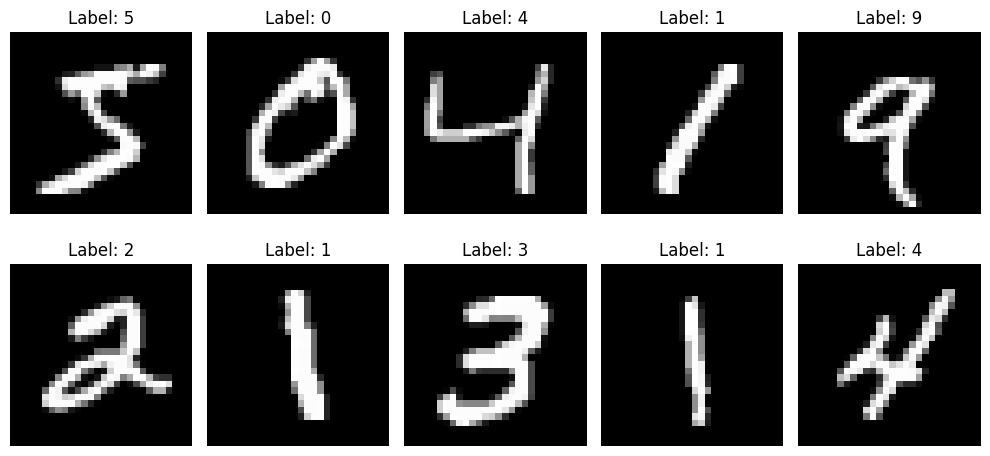

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9082 - loss: 0.3139 - val_accuracy: 0.9632 - val_loss: 0.1303
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9546 - loss: 0.1529 - val_accuracy: 0.9712 - val_loss: 0.0946
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9652 - loss: 0.1146 - val_accuracy: 0.9768 - val_loss: 0.0808
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9716 - loss: 0.0946 - val_accuracy: 0.9790 - val_loss: 0.0724
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9756 - loss: 0.0789 - val_accuracy: 0.9785 - val_loss: 0.0760
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9781 - loss: 0.0682 - val_accuracy: 0.9802 - val_loss: 0.0700
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9804 - loss: 0.0600 - val_accuracy: 0.9790 - val_loss: 0.0704
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0542 - 

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.07122289389371872
Test Accuracy: 0.9797999858856201
Test Accuracy (%): 97.97999858856201


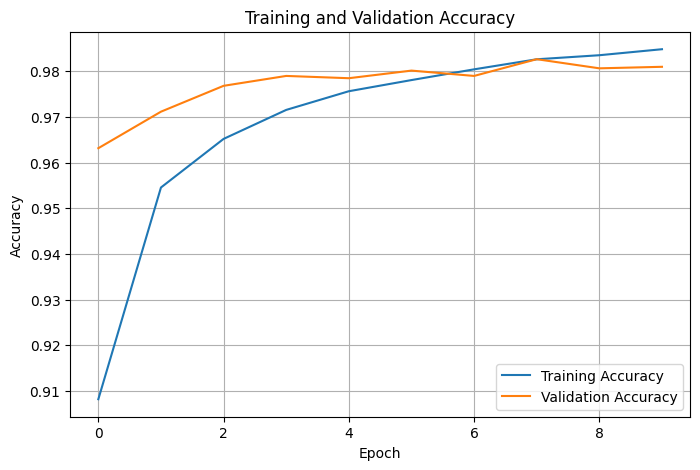

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


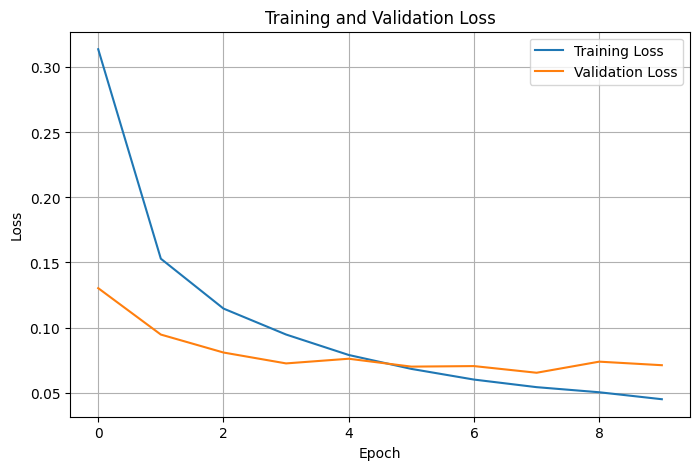

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [12]:
# Select 5 test images
sample_images = x_test[:5]
actual_labels = y_test[:5]

# Predict
predictions = model.predict(sample_images, verbose=0)

# Get predicted class
predicted_labels = np.argmax(predictions, axis=1)

# Display results
for i in range(5):
    print(
        f"Image {i+1}: "
        f"Actual = {actual_labels[i]}, "
        f"Predicted = {predicted_labels[i]}"
    )

Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4


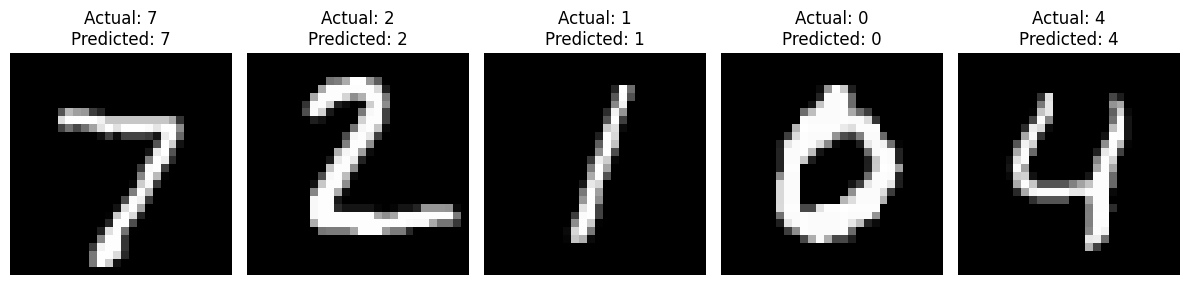

In [13]:
plt.figure(figsize=(12, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(sample_images[i], cmap='gray')

    plt.title(
        f"Actual: {actual_labels[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

experiment_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

experiment_history = experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8894 - loss: 0.3857 - val_accuracy: 0.9577 - val_loss: 0.1525
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9411 - loss: 0.2003 - val_accuracy: 0.9675 - val_loss: 0.1133
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9506 - loss: 0.1622 - val_accuracy: 0.9713 - val_loss: 0.0991
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9575 - loss: 0.1391 - val_accuracy: 0.9732 - val_loss: 0.0945
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9616 - loss: 0.1237 - val_accuracy: 0.9773 - val_loss: 0.0852
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9652 - loss: 0.1102 - val_accuracy: 0.9768 - val_loss: 0.0807
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9679 - loss: 0.1031 - val_accuracy: 0.9768 - val_loss: 0.0820
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9692 - loss: 0.0980 - 

In [15]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Original model accuracy:", test_accuracy)
print("Experimental model accuracy:", experiment_accuracy)

print("\nOriginal model accuracy (%):", test_accuracy * 100)
print("Experimental model accuracy (%):", experiment_accuracy * 100)

Original model accuracy: 0.9797999858856201
Experimental model accuracy: 0.9740999937057495

Original model accuracy (%): 97.97999858856201
Experimental model accuracy (%): 97.40999937057495


In [16]:
print("MODEL COMPARISON")
print("------------------------------")
print(f"Original:     {test_accuracy * 100:.2f}%")
print(f"64 neurons:   {experiment_accuracy * 100:.2f}%")

MODEL COMPARISON
------------------------------
Original:     97.98%
64 neurons:   97.41%
